In [1448]:
import pandas as pd 
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import seaborn as sns


### Setting up each file as a DataFrame and checking that they can be read. 

In [1449]:
bech_df = pd.read_csv("../Data/Bechdel_IMDB_Merge0524.csv")
cin_df = pd.read_csv("../Data/cinatomy_movie_profiles.csv")
osc_df = pd.read_csv("../Data/oscars_df.csv")
horror_df = pd.read_csv("../Data/horror_movies.csv")


In [1450]:
bech_df.head()

,title,year,imdbid,id,bechdelRating,imdbAverageRating,numVotes,runtimeMinutes,genre1,genre2,genre3
0,Miss Jerry,1894,9.0,9779,0,5.4,212.0,45,Romance,NaN,NaN
1,"Story of the Kelly Gang, The",1906,574.0,1349,1,6.0,903.0,70,Action,Adventure,Biography
2,Cleopatra,1912,2101.0,2003,2,5.1,622.0,100,Drama,History,NaN
3,A Florida Enchantment,1914,3973.0,4457,2,5.8,300.0,63,Comedy,NaN,NaN
4,"Birth of a Nation, The",1915,4972.0,1258,2,6.1,26403.0,195,Drama,History,War


In [1451]:
cin_df.head()

,movie_title,pacing_efficiency,originality,family_friendly,plot_quality_rating,plot_quality_reasons_for_liking,plot_quality_reasons_for_disliking,dialogues,end_feeling_emotional_adjective,end_feeling_ending_rating,...,sound_bgm_quality,sound_song_tracks_quality,performance_of_actors,connected,references_contained,cognitive_requirement,technical_knowledge_required,photosensitivity_warnings,animal_harm,trailer_or_spoiler
0,The Shawshank Redemption,4,4,2,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,happy,5,...,5,5,5,5,1,3,1,1,1,1
1,The Godfather,4,5,1,5,"['strong_pacing', 'tight_structure']",[],5,bittersweet,5,...,5,4,5,3,4,4,1,1,4,3
2,The Dark Knight,5,5,1,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,bittersweet,5,...,5,4,5,5,4,4,1,3,1,5
3,The Godfather: Part II,4,5,1,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,bittersweet,5,...,5,4,5,5,5,4,1,1,1,5
4,12 Angry Men,5,5,3,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,energized,5,...,3,1,5,1,1,4,1,1,1,3


In [1452]:
osc_df.head()

,Unnamed: 0,Film,Oscar Year,Film Studio/Producer(s),Award,Year of Release,Movie Time,Movie Genre,IMDB Rating,IMDB Votes,...,Tomatometer Status,Tomatometer Rating,Tomatometer Count,Audience Status,Audience Rating,Audience Count,Tomatometer Top Critics Count,Tomatometer Fresh Critics Count,Tomatometer Rotten Critics Count,Film ID
0,0,Wings,1927/28,Famous Players-Lasky,Winner,1927,144,"Drama,Romance,War",7.5,"12,221",...,Certified-Fresh,93.0,46.0,Upright,78.0,3530.0,9.0,43.0,3.0,2becf7d5-a3de-46ab-ae45-abdd6b588067
1,1,7th Heaven,1927/28,Fox,Nominee,1927,110,"Drama,Romance",7.7,"3,439",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19ed3295-a878-4fd2-8e60-5cd7b5f93dad
2,2,The Racket,1927/28,The Caddo Company,Nominee,1928,84,"Crime,Drama,Film-Noir",6.7,"1,257",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3111c2d8-0908-4093-8ff3-99c89f2f2f08
3,3,The Broadway Melody,1928/29,Metro-Goldwyn-Mayer,Winner,1929,100,"Drama,Musical,Romance",5.7,"6,890",...,Rotten,33.0,24.0,Spilled,21.0,1813.0,7.0,8.0,16.0,de063f3f-2d35-4e1c-8636-6eb4c16bd236
4,4,Alibi,1928/29,Feature Productions,Nominee,1929,91,"Action,Crime,Romance",5.8,765,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,609887c2-877c-43a4-b88c-e40e31096a98


In [1453]:
horror_df.head()

,id,original_title,title,original_language,overview,tagline,release_date,poster_path,popularity,vote_count,vote_average,budget,revenue,runtime,status,adult,backdrop_path,genre_names,collection,collection_name
0,760161,Orphan: First Kill,Orphan: First Kill,en,After escaping from an Estonian psychiatric fa...,There's always been something wrong with Esther.,2022-07-27,/pHkKbIRoCe7zIFvqan9LFSaQAde.jpg,5088.584,902,6.9,0,9572765,99,Released,False,/5GA3vV1aWWHTSDO5eno8V5zDo8r.jpg,"Horror, Thriller",760193.0,Orphan Collection
1,760741,Beast,Beast,en,A recently widowed man and his two teenage dau...,Fight for family.,2022-08-11,/xIGr7UHsKf0URWmyyd5qFMAq4d8.jpg,2172.338,584,7.1,0,56000000,93,Released,False,/2k9tBql5GYH328Krj66tDT9LtFZ.jpg,"Adventure, Drama, Horror",NaN,NaN
2,882598,Smile,Smile,en,"After witnessing a bizarre, traumatic incident...","Once you see it, it’s too late.",2022-09-23,/hiaeZKzwsk4y4atFhmncO5KRxeT.jpg,1863.628,114,6.8,17000000,45000000,115,Released,False,/mVNPfpydornVe4H4UCIk7WevWjf.jpg,"Horror, Mystery, Thriller",NaN,NaN
3,756999,The Black Phone,The Black Phone,en,"Finney Blake, a shy but clever 13-year-old boy...",Never talk to strangers.,2022-06-22,/lr11mCT85T1JanlgjMuhs9nMht4.jpg,1071.398,2736,7.9,18800000,161000000,103,Released,False,/AfvIjhDu9p64jKcmohS4hsPG95Q.jpg,"Horror, Thriller",NaN,NaN
4,772450,Presencias,Presences,es,A man who loses his wife and goes to seclude h...,NaN,2022-09-07,/dgDT3uol3mdvwEg0jt1ble3l9hw.jpg,1020.995,83,7.0,0,0,0,Released,False,/ojfzhdwRemcDt1I6pao6vVLw9AA.jpg,Horror,NaN,NaN


### Checking each dataset's info, shape, and if there are any duplicate rows.

In [1454]:
bech_df.info()
bech_df.duplicated().value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 9718 entries, 0 to 9717
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              9718 non-null   str    
 1   year               9718 non-null   int64  
 2   imdbid             9718 non-null   float64
 3   id                 9718 non-null   int64  
 4   bechdelRating      9718 non-null   int64  
 5   imdbAverageRating  9718 non-null   float64
 6   numVotes           9718 non-null   float64
 7   runtimeMinutes     9718 non-null   str    
 8   genre1             9718 non-null   str    
 9   genre2             8446 non-null   str    
 10  genre3             5807 non-null   str    
dtypes: float64(3), int64(3), str(5)
memory usage: 835.3 KB


False    9718
Name: count, dtype: int64

In [1455]:
cin_df.info()
cin_df.duplicated().value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   movie_title                         1000 non-null   str  
 1   pacing_efficiency                   1000 non-null   int64
 2   originality                         1000 non-null   int64
 3   family_friendly                     1000 non-null   int64
 4   plot_quality_rating                 1000 non-null   int64
 5   plot_quality_reasons_for_liking     1000 non-null   str  
 6   plot_quality_reasons_for_disliking  1000 non-null   str  
 7   dialogues                           1000 non-null   int64
 8   end_feeling_emotional_adjective     1000 non-null   str  
 9   end_feeling_ending_rating           1000 non-null   int64
 10  end_feeling_structural_adjective    1000 non-null   str  
 11  immersive                           1000 non-null   int64
 12  impactful         

False    999
True       1
Name: count, dtype: int64

In [1456]:
osc_df.info()
osc_df.duplicated().value_counts()


<class 'pandas.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        571 non-null    int64  
 1   Film                              571 non-null    str    
 2   Oscar Year                        571 non-null    str    
 3   Film Studio/Producer(s)           571 non-null    str    
 4   Award                             571 non-null    str    
 5   Year of Release                   571 non-null    int64  
 6   Movie Time                        571 non-null    int64  
 7   Movie Genre                       571 non-null    str    
 8   IMDB Rating                       571 non-null    float64
 9   IMDB Votes                        571 non-null    str    
 10  Movie Info                        438 non-null    str    
 11  Genres                            439 non-null    str    
 12  Critic Consensus   

False    571
Name: count, dtype: int64

In [1457]:
horror_df.info()
horror_df.duplicated().value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 32540 entries, 0 to 32539
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 32540 non-null  int64  
 1   original_title     32540 non-null  str    
 2   title              32540 non-null  str    
 3   original_language  32540 non-null  str    
 4   overview           31254 non-null  str    
 5   tagline            12706 non-null  str    
 6   release_date       32540 non-null  str    
 7   poster_path        28066 non-null  str    
 8   popularity         32540 non-null  float64
 9   vote_count         32540 non-null  int64  
 10  vote_average       32540 non-null  float64
 11  budget             32540 non-null  int64  
 12  revenue            32540 non-null  int64  
 13  runtime            32540 non-null  int64  
 14  status             32540 non-null  str    
 15  adult              32540 non-null  bool   
 16  backdrop_path      13545 non-null

False    32540
Name: count, dtype: int64

In [1458]:
print(bech_df.shape)
print(cin_df.shape)
print(osc_df.shape)
print(horror_df.shape)

(9718, 11)
(1000, 27)
(571, 30)
(32540, 20)


Dropping duplicates 

In [1459]:
cin_df.drop_duplicates(keep='first', inplace=True)
cin_df.duplicated().value_counts()

False    999
Name: count, dtype: int64

#### Checking for nulls, and determining if the columns need adjusting or rows need dropping

In [1460]:
bech_df.isnull().sum()

title                   0
year                    0
imdbid                  0
id                      0
bechdelRating           0
imdbAverageRating       0
numVotes                0
runtimeMinutes          0
genre1                  0
genre2               1272
genre3               3911
dtype: int64

Only nulls in the Bechdel Test Dataframe are from subgenres(columns: genre2, genre3)
Most likely needs no adjusting. 

In [1461]:
cin_df.isnull().sum()

movie_title                           0
pacing_efficiency                     0
originality                           0
family_friendly                       0
plot_quality_rating                   0
plot_quality_reasons_for_liking       0
plot_quality_reasons_for_disliking    0
dialogues                             0
end_feeling_emotional_adjective       0
end_feeling_ending_rating             0
end_feeling_structural_adjective      0
immersive                             0
impactful                             0
overall_feeling                       0
visuals                               0
visual_effects                        0
sound_audio_balance_issue             0
sound_bgm_quality                     0
sound_song_tracks_quality             0
performance_of_actors                 0
connected                             0
references_contained                  0
cognitive_requirement                 0
technical_knowledge_required          0
photosensitivity_warnings             0


No nulls found in Cinatomy DataFrame

In [1462]:
osc_df.isnull().sum()

Unnamed: 0                            0
Film                                  0
Oscar Year                            0
Film Studio/Producer(s)               0
Award                                 0
Year of Release                       0
Movie Time                            0
Movie Genre                           0
IMDB Rating                           0
IMDB Votes                            0
Movie Info                          133
Genres                              132
Critic Consensus                    232
Content Rating                      132
Directors                           134
Authors                             134
Actors                              132
Original Release Date               132
Streaming Release Date              133
Production Company                  132
Tomatometer Status                  132
Tomatometer Rating                  132
Tomatometer Count                   132
Audience Status                     135
Audience Rating                     132


Presumably, 132 rows are missing information in the following columns:
- movie info*
- genres*
- critic consensus
- content rating
- directors
- authors
- actors
- original release date
- streaming release date
- production company
- ... and all columns involving Rotten Tomatoes

*( ***asterick*** where null in column might be a concern moving forward)*


In [1463]:
print("Most Recent Release Date:")
print(osc_df['Original Release Date'].max())
print("Earliest Release Date:")
print(osc_df['Original Release Date'].min())


Most Recent Release Date:
2019-11-06
Earliest Release Date:
1927-08-12


The cause of missing values might be the earlier movies. 
***Look more into this in later cleaning.***

In [1464]:
horror_df.isnull().sum()

id                       0
original_title           0
title                    0
original_language        0
overview              1286
tagline              19834
release_date             0
poster_path           4474
popularity               0
vote_count               0
vote_average             0
budget                   0
revenue                  0
runtime                  0
status                   0
adult                    0
backdrop_path        18995
genre_names              0
collection           30234
collection_name      30234
dtype: int64

Nulls in collection_name are fine as is, they are there to let us know that that particular movie is not part of a larger collection.

Nulls in tagline are also fine, not all movies have a tagline, especially the older movies in this dataframe. 
Might ultimately drop this column as it's not incredibly useful. 
Though it could be interesting to see why there is a lack of tagline? 

Columns to drop(due to nulls or repetition): 
- collection (unnecessary since we have collection_name)
- adult(none of these movies are pornography, so all rows have same value)
I don't plan to use these columns and they have a significt number of nulls.


### Dropping unnecessary columns
cin_df is very clean already, so I will not be dropping any columns from this dataset.  

From bech_df i'll be dropping the id column only.
  
From osc_df I will be dropping several columns thaat i do not plan to use for this project:
IMDB Votes, Streaming Release Date, Tomatometer Count, Audience Status, Audience Rating, Audience Count, Tomatometer Top Critics Count, Tomatometer Fresh Critics Count, Tomatometer Rotten Critics Count, Film ID, Unnamed
  
From horror_df I will be dropping poster_path and backdrop_path(as well as adult and collection columns) since I will not be using them in this project.  



In [1465]:
horror_df.drop(['adult', 'id','collection', 'poster_path','backdrop_path', 'vote_count', 'vote_average'], axis=1, inplace=True)
#check if columns dropped
horror_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32540 entries, 0 to 32539
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   original_title     32540 non-null  str    
 1   title              32540 non-null  str    
 2   original_language  32540 non-null  str    
 3   overview           31254 non-null  str    
 4   tagline            12706 non-null  str    
 5   release_date       32540 non-null  str    
 6   popularity         32540 non-null  float64
 7   budget             32540 non-null  int64  
 8   revenue            32540 non-null  int64  
 9   runtime            32540 non-null  int64  
 10  status             32540 non-null  str    
 11  genre_names        32540 non-null  str    
 12  collection_name    2306 non-null   str    
dtypes: float64(1), int64(3), str(9)
memory usage: 3.2 MB


In [1466]:
osc_df.drop(['Unnamed: 0','IMDB Votes', 'Streaming Release Date', 'Actors','Year of Release', 'Tomatometer Count', 'Audience Status', 'Audience Rating', 'Audience Count', 'Tomatometer Top Critics Count', 'Tomatometer Fresh Critics Count', 'Tomatometer Rotten Critics Count', 'Film ID'], axis=1, inplace=True)
#check if columns dropped
osc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Film                     571 non-null    str    
 1   Oscar Year               571 non-null    str    
 2   Film Studio/Producer(s)  571 non-null    str    
 3   Award                    571 non-null    str    
 4   Movie Time               571 non-null    int64  
 5   Movie Genre              571 non-null    str    
 6   IMDB Rating              571 non-null    float64
 7   Movie Info               438 non-null    str    
 8   Genres                   439 non-null    str    
 9   Critic Consensus         339 non-null    str    
 10  Content Rating           439 non-null    str    
 11  Directors                437 non-null    str    
 12  Authors                  437 non-null    str    
 13  Original Release Date    439 non-null    str    
 14  Production Company       439 non-null

In [1467]:
bech_df.drop(["id"], axis=1, inplace=True)
#check if column dropped
bech_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9718 entries, 0 to 9717
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              9718 non-null   str    
 1   year               9718 non-null   int64  
 2   imdbid             9718 non-null   float64
 3   bechdelRating      9718 non-null   int64  
 4   imdbAverageRating  9718 non-null   float64
 5   numVotes           9718 non-null   float64
 6   runtimeMinutes     9718 non-null   str    
 7   genre1             9718 non-null   str    
 8   genre2             8446 non-null   str    
 9   genre3             5807 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 759.3 KB


### Dropping rows  
Dropping rows from horror_df that have nulls in the overview, the number of rows being dropped is a small number in comparison to the dataset as a whole. 




In [1468]:
horror_df.dropna(subset=['overview'], inplace=True)
#check if rows dropped
horror_df.isnull().sum()

original_title           0
title                    0
original_language        0
overview                 0
tagline              18579
release_date             0
popularity               0
budget                   0
revenue                  0
runtime                  0
status                   0
genre_names              0
collection_name      28970
dtype: int64

In [1469]:
# drop rows where status not equal to released 

un_released = horror_df[horror_df['status'] != 'Released'].index
horror_df.drop(un_released, inplace=True)

#check rows were droppecd
horror_df['status'].value_counts()


status
Released    31142
Name: count, dtype: int64

As suspected, movies with no movie info are earlier movies(before 1958), based of this I believe it'll be fine drop these rows.

In [1470]:
no_movieinfo = osc_df[osc_df['Movie Info'].isnull()] 
no_movieinfo['Original Release Date'].max()

'1958-09-20'

Dropping all rows with null in the Movie Info column also resolved the nulls in almost every other column (significantly- Genres column)

In [1471]:
osc_df.dropna(subset=['Movie Info'], inplace=True)
#check if rows dropped, how other columns were effected as well
osc_df.isnull().sum()

Film                         0
Oscar Year                   0
Film Studio/Producer(s)      0
Award                        0
Movie Time                   0
Movie Genre                  0
IMDB Rating                  0
Movie Info                   0
Genres                       0
Critic Consensus           100
Content Rating               0
Directors                    2
Authors                      2
Original Release Date        0
Production Company           0
Tomatometer Status           0
Tomatometer Rating           0
dtype: int64

### Replace Values

In [1472]:
#replacing 0 runtime values with NaN to avoid skewing data
#researched a few movies with '0' runtimes, obviously not correct.

horror_df['runtime'] = horror_df['runtime'].replace(0, np.nan)
horror_df['runtime'].isnull().sum()

np.int64(1652)

In [1473]:
bech_df['runtimeMinutes'] = bech_df['runtimeMinutes'].replace("\\N", np.nan)
#when trying to change the datatype of runtimeMinutes column, I was getting a ValueError: invalid literal for int() with base 10: '\N' error.

datatype_issues = bech_df[bech_df['runtimeMinutes'] == "\\N"] 
datatype_issues['runtimeMinutes'].value_counts()


Series([], Name: count, dtype: int64)

### Fix datatypes  
  
Checking the datatypes are appropriate and changing them if needed.  
Changing release date/year of horror_df, bech_df, and osc_df to datetime.  
Oscar Year format is Year/Year ex. 1986/87.  
**need to figure out what to do about oscar year format, could possibly keep as string?**




In [1474]:

horror_df['release_date'] = pd.to_datetime(horror_df['release_date'])
bech_df['year'] = pd.to_datetime(bech_df['year'])
osc_df['Original Release Date'] = pd.to_datetime(osc_df['Original Release Date'])



In [1475]:
bech_df['runtimeMinutes'] = bech_df['runtimeMinutes'].astype(float)
osc_df['Movie Time'] = osc_df['Movie Time'].astype(float)


In [1476]:
horror_df.dtypes

original_title                  str
title                           str
original_language               str
overview                        str
tagline                         str
release_date         datetime64[us]
popularity                  float64
budget                        int64
revenue                       int64
runtime                     float64
status                          str
genre_names                     str
collection_name                 str
dtype: object

In [1477]:
bech_df.dtypes

title                           str
year                 datetime64[ns]
imdbid                      float64
bechdelRating                 int64
imdbAverageRating           float64
numVotes                    float64
runtimeMinutes              float64
genre1                          str
genre2                          str
genre3                          str
dtype: object

In [1478]:
cin_df.dtypes

movie_title                             str
pacing_efficiency                     int64
originality                           int64
family_friendly                       int64
plot_quality_rating                   int64
plot_quality_reasons_for_liking         str
plot_quality_reasons_for_disliking      str
dialogues                             int64
end_feeling_emotional_adjective         str
end_feeling_ending_rating             int64
end_feeling_structural_adjective        str
immersive                             int64
impactful                             int64
overall_feeling                       int64
visuals                               int64
visual_effects                        int64
sound_audio_balance_issue              bool
sound_bgm_quality                     int64
sound_song_tracks_quality             int64
performance_of_actors                 int64
connected                             int64
references_contained                  int64
cognitive_requirement           

In [1479]:
osc_df.dtypes

Film                                  str
Oscar Year                            str
Film Studio/Producer(s)               str
Award                                 str
Movie Time                        float64
Movie Genre                           str
IMDB Rating                       float64
Movie Info                            str
Genres                                str
Critic Consensus                      str
Content Rating                        str
Directors                             str
Authors                               str
Original Release Date      datetime64[us]
Production Company                    str
Tomatometer Status                    str
Tomatometer Rating                float64
dtype: object

### Rename Columns 
For consistency, when we start making SQL tables and queries.

In [1480]:
horror_df.rename(columns={'popularity': 'tmdb_rating', 'genre_names': 'movie_genres'}, inplace=True)

#checking if column name changed 
horror_df.info()

<class 'pandas.DataFrame'>
Index: 31142 entries, 0 to 32537
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   original_title     31142 non-null  str           
 1   title              31142 non-null  str           
 2   original_language  31142 non-null  str           
 3   overview           31142 non-null  str           
 4   tagline            12628 non-null  str           
 5   release_date       31142 non-null  datetime64[us]
 6   tmdb_rating        31142 non-null  float64       
 7   budget             31142 non-null  int64         
 8   revenue            31142 non-null  int64         
 9   runtime            29490 non-null  float64       
 10  status             31142 non-null  str           
 11  movie_genres       31142 non-null  str           
 12  collection_name    2281 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(8)
memory usage: 3.3 MB


In [1481]:
bech_df.rename(columns={
    "year": "release_date",
    "imdbAverageRating": "imdb_rating",
    "bechdelRating": "bechdel_rating",
    "runtimeMinutes": "runtime",
    "numVotes": "imdb_votes"
    }, inplace=True)

#checking if column names changed
bech_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9718 entries, 0 to 9717
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title           9718 non-null   str           
 1   release_date    9718 non-null   datetime64[ns]
 2   imdbid          9718 non-null   float64       
 3   bechdel_rating  9718 non-null   int64         
 4   imdb_rating     9718 non-null   float64       
 5   imdb_votes      9718 non-null   float64       
 6   runtime         9710 non-null   float64       
 7   genre1          9718 non-null   str           
 8   genre2          8446 non-null   str           
 9   genre3          5807 non-null   str           
dtypes: datetime64[ns](1), float64(4), int64(1), str(4)
memory usage: 759.3 KB


In [1482]:
cin_df.rename(columns={"movie_title": "title"}, inplace=True)
#checking if column name changed
cin_df.info()

<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   title                               999 non-null    str  
 1   pacing_efficiency                   999 non-null    int64
 2   originality                         999 non-null    int64
 3   family_friendly                     999 non-null    int64
 4   plot_quality_rating                 999 non-null    int64
 5   plot_quality_reasons_for_liking     999 non-null    str  
 6   plot_quality_reasons_for_disliking  999 non-null    str  
 7   dialogues                           999 non-null    int64
 8   end_feeling_emotional_adjective     999 non-null    str  
 9   end_feeling_ending_rating           999 non-null    int64
 10  end_feeling_structural_adjective    999 non-null    str  
 11  immersive                           999 non-null    int64
 12  impactful               

In [1483]:
osc_df.rename(columns={
    "Film": "title",
    "Oscar Year": "oscar_year",
    "Film Studio/Producer(s)": "studio_producer",
    "Award": "oscar_award",
    "Movie Time": "runtime",
    "Movie Info": "overview",
    "Genres": "genres",
    "Critic Consensus": "critic_consensus",
    "Content Rating": "content_rating",
    "Directors": "directors",
    "Authors": "authors",
    "Original Release Date": "release_date",
    "Movie Genre": "movie_genre",
    "Production Company": "production_company",
    "Tomatometer Rating": "tomatometer_rating",
    "IMDB Rating": "imdb_rating",
    "Tomatometer Status": "tomatometer_status"}, inplace= True)

osc_df.info()

<class 'pandas.DataFrame'>
Index: 438 entries, 0 to 561
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   title               438 non-null    str           
 1   oscar_year          438 non-null    str           
 2   studio_producer     438 non-null    str           
 3   oscar_award         438 non-null    str           
 4   runtime             438 non-null    float64       
 5   movie_genre         438 non-null    str           
 6   imdb_rating         438 non-null    float64       
 7   overview            438 non-null    str           
 8   genres              438 non-null    str           
 9   critic_consensus    338 non-null    str           
 10  content_rating      438 non-null    str           
 11  directors           436 non-null    str           
 12  authors             436 non-null    str           
 13  release_date        438 non-null    datetime64[us]
 14  production

### Normalizing Genre Columns  
**horror_df: movie_genres**  
^ string with comma seperating each genre; how I want each dataframe's genre column to be.
  
bech_df: genre1, genre2, genre3  
osc_df: movie_genre, genres


In [1484]:
# create a function to unify the genre columns into one column for each dataframe
# string separated by commas

def unify_genres(df, genre_columns):
    for col in genre_columns:
        df[col] = df[col].fillna('').astype(str).apply(lambda x: x.split(',') if ',' in x else [x] if x else [])
    df['movie_genres'] = df[genre_columns].apply(
        lambda row: list({g.strip() for col in genre_columns for g in row[col] if g.strip()}),
        axis=1
    )
    df['movie_genres'] = df['movie_genres'].apply(lambda x: ', '.join(x))
    return df


# mixture of using chatgpt and www.slingacademy.com
# the code chatgpt gave me didn't work exactly the way I had hoped and needed modifications to get the desired output

unify_genres(bech_df, ['genre1', 'genre2', 'genre3'])
unify_genres(osc_df, ['movie_genre', 'genres'])

,title,oscar_year,studio_producer,oscar_award,runtime,movie_genre,imdb_rating,overview,genres,critic_consensus,content_rating,directors,authors,release_date,production_company,tomatometer_status,tomatometer_rating,movie_genres
0,Wings,1927/28,Famous Players-Lasky,Winner,144.0,"[Drama, Romance, War]",7.5,"With World War I afoot, David Armstrong (Richa...","[Action & Adventure, Classics]",Subsequent war epics may have borrowed heavily...,PG-13,William Wellman,"Hope Loring, Louis D. Lighton",1927-08-12,Unknown,Certified-Fresh,93.0,"War, Romance, Action & Adventure, Drama, Classics"
3,The Broadway Melody,1928/29,Metro-Goldwyn-Mayer,Winner,100.0,"[Drama, Musical, Romance]",5.7,"Vaudeville sisters ""Hank"" (Bessie Love) and Qu...","[Musical & Performing Arts, Romance]",The Broadway Melody is interesting as an examp...,NR,Harry Beaumont,"James Gleason, Norman Houston, Sarah Y. Mason",1929-02-01,MGM Home Entertainment,Rotten,33.0,"Musical & Performing Arts, Musical, Drama, Rom..."
6,In Old Arizona,1928/29,Fox,Nominee,95.0,[Western],5.6,"In this early Western, notorious bandit the Ci...","[Action & Adventure, Classics, Western, Rom...",NaN,NR,"Irving Cummings, Raoul Walsh",Tom Barry,1928-12-25,20th Century Fox Film Corporation,Rotten,56.0,"Classics, Romance, Western, Action & Adventure"
9,The Big House,1929/30,Cosmopolitan,Nominee,87.0,"[Crime, Drama, Thriller]",7.1,"After being convicted of manslaughter, drunk d...","[Classics, Drama]",NaN,NR,George W. Hill,"Frances Marion, Martin Flavin, Joseph Farnham,...",1930-05-14,Warner Bros.,Fresh,75.0,"Thriller, Crime, Drama, Classics"
13,Cimarron,1930/31,RKO Radio,Winner,123.0,"[Drama, Western]",5.9,"In 1889, adventurous lawyer and newspaper edit...","[Classics, Drama, Western]",Cimarron is supported by a strong performance ...,NR,Wesley Ruggles,"Howard Estabrook, Edna Ferber",1931-01-26,MGM Home Entertainment,Rotten,50.0,"Drama, Western, Classics"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,A Star Is Born,2018,"Bill Gerber, Bradley Cooper, and Lynette Howel...",Nominee,136.0,"[Drama, Music, Romance]",7.6,Seasoned musician Jackson Maine discovers -- a...,[Drama],"With appealing leads, deft direction, and an a...",R,Bradley Cooper,"Will Fetters, Eric Roth, Bradley Cooper",2018-10-05,Warner Bros. Pictures,Certified-Fresh,90.0,"Music, Drama, Romance"
553,Vice,2018,"Dede Gardner, Jeremy Kleiner, Adam McKay, and ...",Nominee,132.0,"[Biography, Comdey, Drama]",7.2,Gov. George W. Bush of Texas picks Dick Cheney...,[Drama],"Vice takes scattershot aim at its targets, but...",R,Adam McKay,Adam McKay,2018-12-25,Annapurna Pictures,Fresh,65.0,"Biography, Comdey, Drama"
557,The Irishman,2019,"Martin Scorsese, Robert De Niro, Jane Rosentha...",Nominee,209.0,"[Biography, Crime, Drama]",7.8,"In the 1950s, truck driver Frank Sheeran gets ...","[Drama, Mystery & Suspense]",An epic gangster drama that earns its extended...,R,Martin Scorsese,Steven Zaillian,2019-11-01,Netflix,Certified-Fresh,96.0,"Mystery & Suspense, Crime, Biography, Drama"
559,Joker,2019,"Todd Phillips, Bradley Cooper, and Emma Tillin...",Nominee,122.0,"[Crime, Drama, Thriller]",8.4,"Forever alone in a crowd, failed comedian Arth...","[Action & Adventure, Drama, Mystery & Suspense]",Joker gives its infamous central character a c...,R,Todd Phillips,"Todd Phillips, Scott Silver",2019-10-04,Warner Bros. Pictures,Fresh,68.0,"Mystery & Suspense, Crime, Thriller, Action & ..."


Now I can drop the columns that have been unified

In [1485]:
osc_df.drop(['movie_genre', 'genres'], axis=1, inplace=True)
bech_df.drop(['genre1', 'genre2', 'genre3'], axis=1, inplace=True)

### Changing the oscar_award column  
issues later with duplicate titles because of this column  
change to the number of noms and wins for each movie_id/title  


In [1486]:
#checking counts of each occurence
osc_df['oscar_award'].value_counts()

oscar_award
Nominee    356
Winner      82
Name: count, dtype: int64

In [1487]:
# get the counts of each occurence(nominee or winner)
counts = osc_df.groupby(['title', 'oscar_award']).size().reset_index(name='award_count')
counts_df = counts.pivot(index='title', columns='oscar_award', values='award_count').fillna(0).astype(int)

#merge back into original df

osc_df = pd.merge(counts_df, osc_df, on='title', how='left')

#rename columns to osc_nomination and osc_win for consistency 
#drop oscar_award column (no longer needed)
osc_df.rename(columns={'Nominee': 'osc_nomination', 'Winner': 'osc_win'}, inplace=True)
osc_df.drop(['oscar_award'], axis=1, inplace=True)

#check 
osc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   title               438 non-null    str           
 1   osc_nomination      438 non-null    int64         
 2   osc_win             438 non-null    int64         
 3   oscar_year          438 non-null    str           
 4   studio_producer     438 non-null    str           
 5   runtime             438 non-null    float64       
 6   imdb_rating         438 non-null    float64       
 7   overview            438 non-null    str           
 8   critic_consensus    338 non-null    str           
 9   content_rating      438 non-null    str           
 10  directors           436 non-null    str           
 11  authors             436 non-null    str           
 12  release_date        438 non-null    datetime64[us]
 13  production_company  438 non-null    str           
 14  tomat

## Creating DataFrames  
(to be turned into tables)


movie table, ratings/scores/ awards, financials, cinatomy/subjective, studio/directors/producers


In [1488]:
df1= horror_df[['title', 'original_title', 'original_language', 'overview', 'tagline', 'collection_name', 'runtime', 'release_date', 'movie_genres']]
df2= osc_df[['title', 'overview', 'runtime', 'release_date', 'movie_genres']]
df3= bech_df[['title','runtime', 'release_date', 'movie_genres']]
df4= cin_df[['title']]


cin_mer = pd.merge(df4, df1, on='title', how= 'outer')
osbe_mer = pd.merge(df2, df3, on='title', how='left')
movies_df = pd.merge(cin_mer, osbe_mer, on= 'title', how= 'outer')


movies_df.drop_duplicates(subset=['title', 'release_date'], keep='first')

#merging these dataframes has created new columns, with x or y suffixes

#rename columns overview_x to overview
movies_df.rename(columns={'overview_x': 'overview'}, inplace=True)


#drop columns overview_y, runtime_x, release_date_x, movie_genres_x, runtime_y, release_date_y, movie_genres_y (very insignificant number, most likely off by a character)
movies_df.drop(['overview_y', 'runtime_x', 'release_date_x', 'movie_genres_x', 'runtime_y', 'release_date_y', 'movie_genres_y'], axis=1, inplace=True)

movies_df.drop_duplicates(subset=['title'], inplace=True)

movies_df.insert(0, 'movie_id', range(1, len(movies_df) + 1))
movies_df.info()


# checking all movie_id values are unique 
print(movies_df['movie_id'].nunique())
print(movies_df['title'].nunique())



<class 'pandas.DataFrame'>
Index: 29442 entries, 0 to 32331
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   movie_id           29442 non-null  int64         
 1   title              29442 non-null  str           
 2   original_title     28282 non-null  str           
 3   original_language  28282 non-null  str           
 4   overview           28282 non-null  str           
 5   tagline            11560 non-null  str           
 6   collection_name    2217 non-null   str           
 7   runtime            26764 non-null  float64       
 8   release_date       28282 non-null  datetime64[us]
 9   movie_genres       28282 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(7)
memory usage: 2.5 MB
29442
29442


In [1489]:
# financials table ---  movie_id, budget, revenue 
df1 = movies_df[['movie_id', 'title']]
df2 = horror_df[['title', 'budget', 'revenue']]

fin_info = pd.merge(df1, df2, on="title", how= 'right')
financials_df = fin_info.drop_duplicates().reset_index(drop=True)

#movie_id column datatype needs to be turned back into an integer
financials_df['movie_id'] = financials_df['movie_id'].astype('Int64')


# drop rows with NaN for budget and revenue?
financials_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 29188 entries, 0 to 29187
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  29188 non-null  Int64
 1   title     29188 non-null  str  
 2   budget    29188 non-null  int64
 3   revenue   29188 non-null  int64
dtypes: Int64(1), int64(2), str(1)
memory usage: 940.8 KB


In [1490]:
# ratings table  movie_id, tmdb rating, imdb rating, tomatometer rating, bechdel rating, content rating, oscar award

df1 = movies_df[['movie_id', 'title']]
df2 = horror_df[['title', 'tmdb_rating']]
df3 =osc_df[['title', 'osc_nomination', 'osc_win', 'oscar_year', 'imdb_rating', 'critic_consensus', 'tomatometer_status', 'tomatometer_rating']]
df4 = bech_df[['title', 'bechdel_rating', 'imdb_rating']]


#merge all four dataframes

ratings1 = pd.merge(df2, df3, on='title', how='outer')
ratings2 = pd.merge(ratings1, df4, on= 'title', how= 'outer')
ratings_df = pd.merge(df1, ratings2, on= 'title', how= "left")

# combining _x and _y suffix columns into one column and dropping the suffix columns
ratings_df['imdb_rating'] = ratings_df['imdb_rating_x'].combine_first(ratings_df['imdb_rating_y'])
ratings_df.drop(['imdb_rating_x', 'imdb_rating_y'], axis=1, inplace=True)

#movie_id column datatype needs to be turned back into an integer
ratings_df['movie_id'] = ratings_df['movie_id'].astype('Int64')

ratings_df.info()



<class 'pandas.DataFrame'>
RangeIndex: 32484 entries, 0 to 32483
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            32484 non-null  Int64  
 1   title               32484 non-null  str    
 2   tmdb_rating         31285 non-null  float64
 3   osc_nomination      488 non-null    float64
 4   osc_win             488 non-null    float64
 5   oscar_year          488 non-null    str    
 6   critic_consensus    368 non-null    str    
 7   tomatometer_status  488 non-null    str    
 8   tomatometer_rating  488 non-null    float64
 9   bechdel_rating      2306 non-null   float64
 10  imdb_rating         2506 non-null   float64
dtypes: Int64(1), float64(6), str(4)
memory usage: 2.8 MB


In [1491]:
# affiliates table affiliate_id, stuio, director, producer 

df1= movies_df[['movie_id', 'title']]
df2 = osc_df[['title', 'studio_producer', 'directors', 'authors', 'production_company']]

aff_info = pd.merge(df1, df2, on='title', how='outer')
affiliates_df = aff_info.drop_duplicates().reset_index(drop=True)

#movie_id column datatype needs to be turned back into an integer
affiliates_df['movie_id'] = affiliates_df['movie_id'].astype('Int64')


affiliates_df.info()



<class 'pandas.DataFrame'>
RangeIndex: 29446 entries, 0 to 29445
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   movie_id            29446 non-null  Int64
 1   title               29446 non-null  str  
 2   studio_producer     438 non-null    str  
 3   directors           436 non-null    str  
 4   authors             436 non-null    str  
 5   production_company  438 non-null    str  
dtypes: Int64(1), str(5)
memory usage: 1.4 MB


In [1492]:
# cinatomy/subjective --- table movie_id, every column i think i'll use except title from cinatomy

df1= movies_df[['movie_id', 'title']]
df2 = cin_df[['title', 'originality', 'immersive', 'impactful', 'connected', 'visuals', 'visual_effects', 'performance_of_actors', 'trailer_or_spoiler', 'plot_quality_rating', 'end_feeling_ending_rating', 'pacing_efficiency' ]]


cin_info = pd.merge(df1, df2, on='title', how='right')
cinatomy_df = cin_info.drop_duplicates().reset_index(drop=True)

#movie_id column datatype needs to be turned back into an integer
cinatomy_df['movie_id'] = cinatomy_df['movie_id'].astype('Int64')


cinatomy_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   movie_id                   999 non-null    Int64
 1   title                      999 non-null    str  
 2   originality                999 non-null    int64
 3   immersive                  999 non-null    int64
 4   impactful                  999 non-null    int64
 5   connected                  999 non-null    int64
 6   visuals                    999 non-null    int64
 7   visual_effects             999 non-null    int64
 8   performance_of_actors      999 non-null    int64
 9   trailer_or_spoiler         999 non-null    int64
 10  plot_quality_rating        999 non-null    int64
 11  end_feeling_ending_rating  999 non-null    int64
 12  pacing_efficiency          999 non-null    int64
dtypes: Int64(1), int64(11), str(1)
memory usage: 102.6 KB


### drop title column from each dataframe


In [1493]:
financials_df.drop(["title"], axis=1, inplace=True)
affiliates_df.drop(["title"], axis=1, inplace=True)
ratings_df.drop(["title"], axis=1, inplace=True)
cinatomy_df.drop(["title"], axis=1, inplace=True)


### Turning DataFrames into CSV Files


In [1494]:
movies_df.to_csv('../Data/movies.csv')
financials_df.to_csv('../Data/financials.csv')
affiliates_df.to_csv('../Data/affiliates.csv')
ratings_df.to_csv('../Data/ratings.csv')
cinatomy_df.to_csv('../Data/cinatomy.csv')

### Creating a Database and load new dataframes as tables

In [1495]:

connection = sqlite3.connect('../Data/perfect_movie.db')

movies_df.to_sql('movies', connection, if_exists='replace', index=False)
financials_df.to_sql('financials', connection, if_exists='replace', index=False)
affiliates_df.to_sql('affiliates', connection,  if_exists='replace',index=False)
ratings_df.to_sql('ratings', connection, if_exists='replace', index=False)
cinatomy_df.to_sql('cinatomy', connection, if_exists='replace', index=False)


connection.close()

In [1542]:
connection = sqlite3.connect('../Data/perfect_movie.db')

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", connection)

,name
0,movies
1,financials
2,affiliates
3,ratings
4,cinatomy


It's not as simple as just looking at ALL the data.
You have to take into account that technology, marketing, streaming services, the internet have all grown and continue to grow. These factors have created an envirment where more movies are being made in larger quantities.

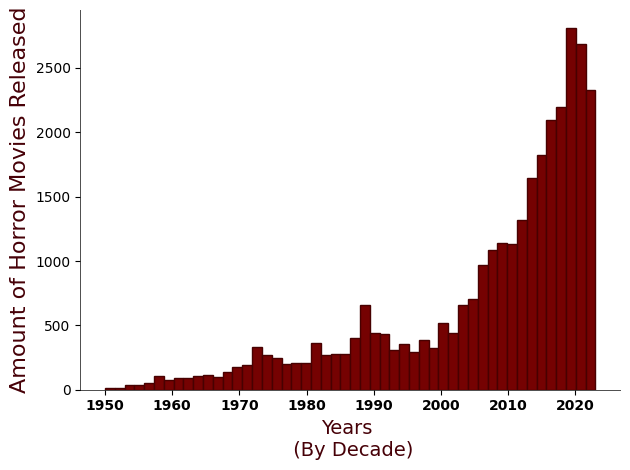

In [1543]:
release_data = horror_df['release_date']
plt.hist(release_data, bins=50, color="#750202", edgecolor="#470101")


plt.xlabel('Years \n (By Decade)', fontsize=14, color= "#460007")
plt.ylabel('Amount of Horror Movies Released',fontsize=16,  color= "#460007" )

plt.xticks(fontweight= "bold")
ax= plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
    spine.set_alpha(0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig('../Visualizations/horror_movie_release_freq.png')
plt.show()

Top 10 horror movies with the highest revenue

don't forget inflation! most of these movies will be newer because of that. Which is why revenue isn't the end all be all of finding the perfect Horror Movie. It's not perfect but does give us some insights. 

C:\Users\jessi\AppData\Local\Temp\ipykernel_8904\901070503.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(custom_labels, color = "#122903", fontsize=10, fontweight="bold", rotation=30, ha="right")


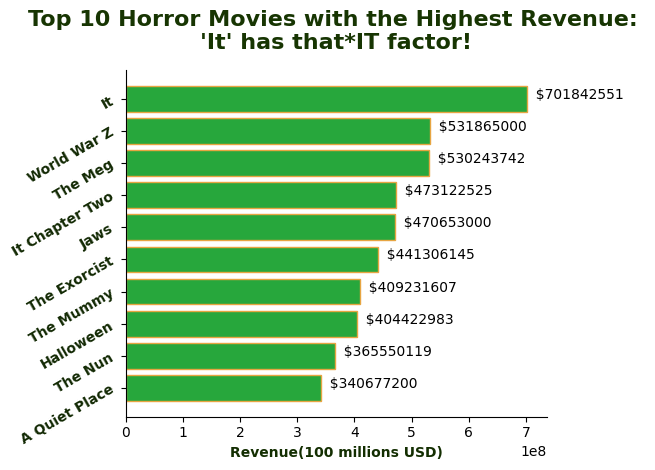

In [1544]:
category = "title"
values = "revenue"
movie_rev = horror_df.groupby(category)[values].sum().sort_values(ascending=False)
movie_rev_10 = movie_rev.head(10)



fig, ax = plt.subplots()


ax.barh(movie_rev_10.index, movie_rev_10.values, align='center', edgecolor= "#E7A542", color="#27A73C")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()  
ax.set_xlabel('Revenue(100 millions USD)', color= "#132E01", fontweight= 'bold')
ax.set_title("Top 10 Horror Movies with the Highest Revenue: \n'It' has that*IT factor!", color= "#173502", fontsize=16, fontweight='bold', pad= 15)

custom_labels = movie_rev_10.index
ax.set_yticklabels(custom_labels, color = "#122903", fontsize=10, fontweight="bold", rotation=30, ha="right")


for index, value in enumerate(movie_rev_10.values):
    plt.text(value + 50, index, str(f"  ${movie_rev_10.values[index]}"))

plt.tight_layout()
plt.savefig('../Visualizations/top_horrormovie_rev.png')
plt.show()

We are going to go a little broader here, and look at movie collections instead of just individual movies.

What percent of horrror movies are part of a larger collection? 

Not every movie(or specifically the creators of the movie) hope to become part of a larger collection, but many would probably like to(more movies = more revenue). You have already built a world to be explored, with societal/paranormal/etc. rules to follow: leaving less work overall. 

Some movies gain so much popularity the inevietably become part of a collection even though original intent was to be a standalone movie. 

C:\Users\jessi\AppData\Local\Temp\ipykernel_8904\4085183418.py:34: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend = ax.legend(


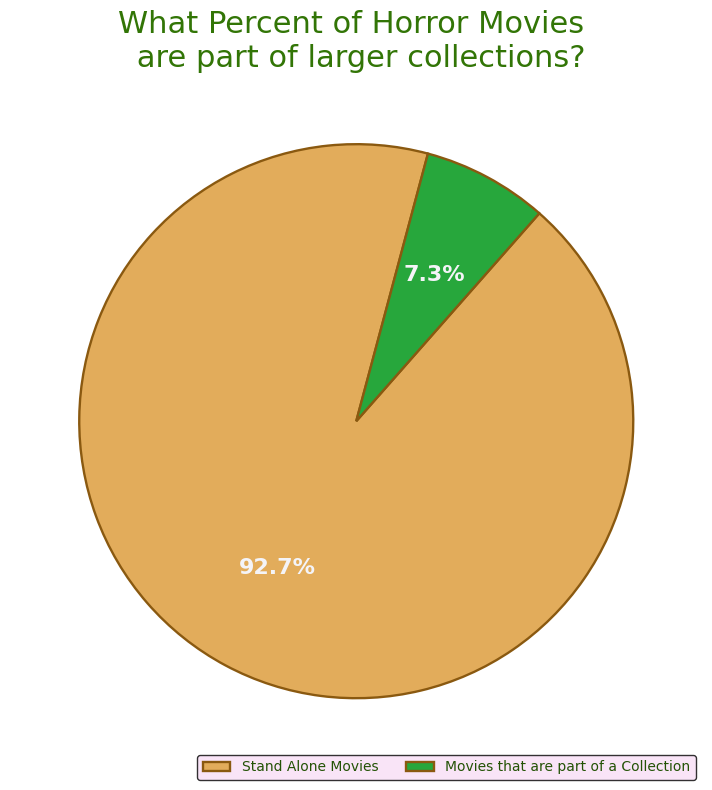

In [1545]:
standalone = horror_df['collection_name'].isna().sum()
incollection = horror_df['collection_name'].count()
pie_data = [standalone, incollection]
pie_series = pd.Series(pie_data)


fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotext = ax.pie(
    pie_series,
    labels=None,
    startangle= 75,
    colors=["#E2AC5B", "#27A73C"],
    autopct= "%1.1f%%",
    wedgeprops={
        'edgecolor': "#8A5910", 
        'linewidth': 1.7,     
        'antialiased': True}
    )

ax.set_title(
    "What Percent of Horror Movies \n are part of larger collections?",
    fontsize= 22,
    color= "#327506",
    loc="center"
    )

for autotext in autotext:
    autotext.set_fontsize(16)
    autotext.set_color("#f4f4f8")
    autotext.set_weight("bold")


legend = ax.legend(
    wedges,
    pie_series.index,
    labels= ["Stand Alone Movies","Movies that are part of a Collection"],
    loc="center right",
    bbox_to_anchor = (1, 0),
    ncol= 2,
    frameon=True,                     
    facecolor="#F8DEF5",           
    edgecolor='black'   
)
for text in legend.get_texts():
    text.set_color("#235205")



plt.tight_layout()

plt.savefig('../Visualizations/collectionvsstanalone.png')
plt.show()


Does having a higher budget guarantee a good movie? 
It doesn't guarantee a high revenue.

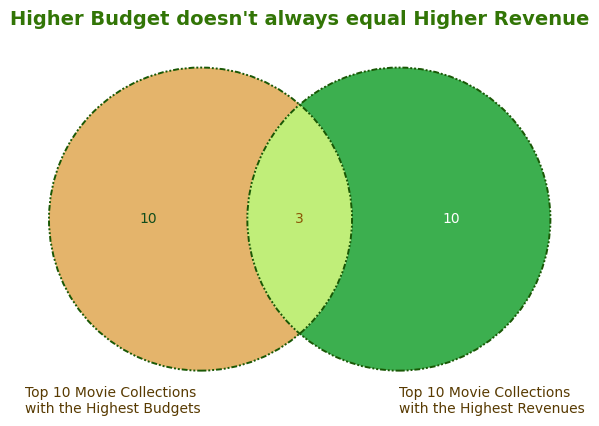

Top 10 horror movie collections with highest revenues:
collection_name
Resident Evil Collection          1233421727
It Collection                     1174965076
Saw Collection                     977089863
Paranormal Activity Collection     886011827
The Conjuring Collection           840887456
Jaws Collection                    798405075
Annabelle Collection               794816136
Scream Collection                  744475660
Final Destination Collection       666766477
Halloween Collection               652766751
Name: revenue, dtype: int64
Top 10 horror movies collections with highest budgets:
collection_name
Resident Evil Collection          288000000
Blade Collection                  164000000
Final Destination Collection      161000000
Van Helsing Collection            160000000
The Meg Collection                150000000
The Exorcist Collection           144300000
Scream Collection                 142000000
Alien Collection                  131000000
The Hannibal Lecter Collecti

In [1546]:
# this block of code is to get the insights I will put into the Venn diagram
movie_collection_revenue = horror_df.groupby('collection_name')['revenue'].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False).head(10)
movie_coll_rev = pd.Series(movie_coll_rev) 


movie_collection_budget = horror_df.groupby('collection_name')['budget'].sum()
movie_coll_budget = movie_collection_budget.sort_values(ascending=False).head(10)
movie_coll_budget = pd.Series(movie_coll_budget) 

# get the movies where both lists intersect
lside = movie_coll_budget.index
rside = movie_coll_rev.index
middle = set(lside).intersection(set(rside))


venn = venn2(subsets = (10, 10, 3),
    set_labels = ('Top 10 Movie Collections \nwith the Highest Budgets', 'Top 10 Movie Collections \nwith the Highest Revenues'), 
    set_colors=("#E2AC5B", "#27A73C"),
    alpha= 0.9)

venn2_circles(subsets=(10,10,3),
            color= "#195805",
            linestyle= (0, (3, 1, 1, 1, 1, 1)),
            linewidth= 1.4) 

venn.set_labels[0].set_fontsize(10)
venn.set_labels[1].set_fontsize(10)
venn.set_labels[0].set_color("#583a01")
venn.set_labels[1].set_color("#583a01")

if venn.get_label_by_id('10'):  # leftside
    venn.get_label_by_id('10').set_color( "#114D1B")

if venn.get_label_by_id('01'):  # rigthside
    venn.get_label_by_id('01').set_color('white')

if venn.get_label_by_id('11'):  # intersection
    venn.get_label_by_id('11').set_color("#8B5605")


plt.title("Higher Budget doesn't always equal Higher Revenue",
        color= "#327506",
        fontsize=14,
        fontweight="bold",
        pad= 5)

plt.tight_layout()
plt.savefig('../Visualizations/collrev_bud_Venn.png')
plt.show()




print("Top 10 horror movie collections with highest revenues:")
print(movie_coll_rev)
print("Top 10 horror movies collections with highest budgets:")
print(movie_coll_budget)
print("Horror movie collections that are in both lists: (top 10 highest revenue & top ten highest budget for horror movie collections)")
print(middle)

### a closer look at what the above Venn diagram shows:

C:\Users\jessi\AppData\Local\Temp\ipykernel_8904\212199677.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, color = "#234603", fontsize=10, fontweight="bold", rotation=30, ha="right")


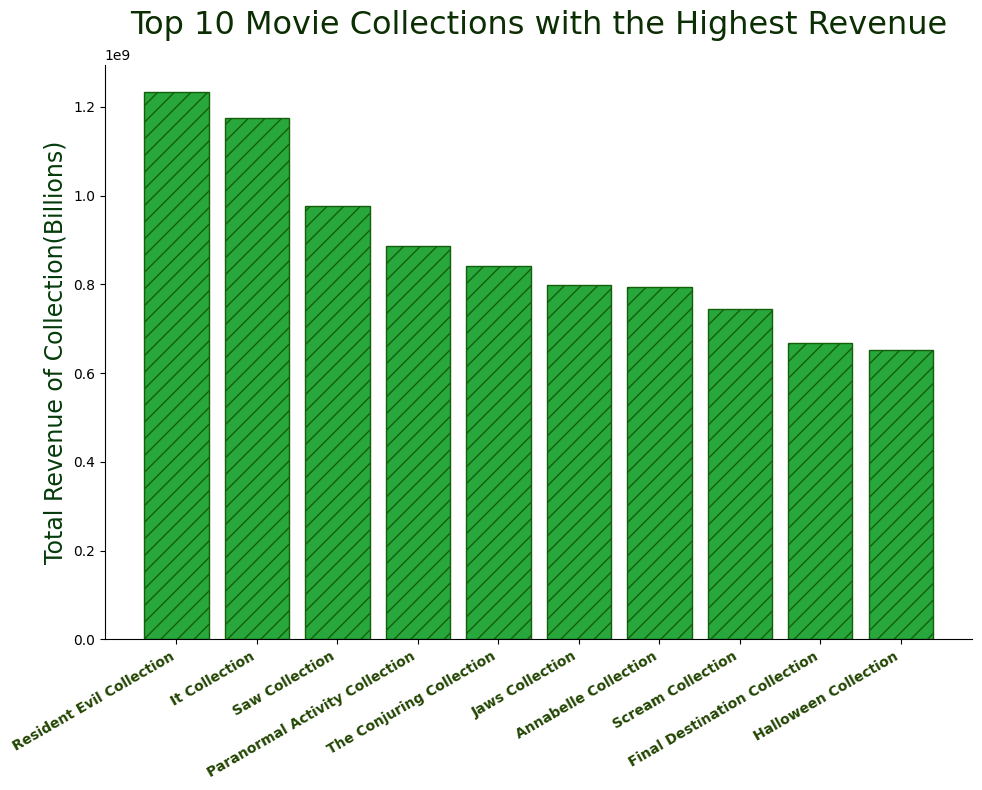

In [1547]:
category = "collection_name"
values = "revenue"
movie_collection_revenue = horror_df.groupby(category)[values].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False) 

collection_rev_10 = movie_coll_rev.head(10)

plt.figure(figsize=(10,8))
plt.bar(collection_rev_10.index, collection_rev_10.values, color= "#27A73C", edgecolor= "#145f0a", hatch= "//")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Top 10 Movie Collections with the Highest Revenue",
          fontsize= 23,
          color= "#0B2E02",
          pad= 22,
          loc="center")

plt.ylabel("Total Revenue of Collection(Billions)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

custom_labels = collection_rev_10.index
ax.set_xticklabels(custom_labels, color = "#234603", fontsize=10, fontweight="bold", rotation=30, ha="right")

plt.tight_layout()
plt.savefig('../Visualizations/top_movie_collection_rev.png')
plt.show()

C:\Users\jessi\AppData\Local\Temp\ipykernel_8904\3659290884.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, color = "#234603",  fontsize=10, fontweight="bold", rotation=30, ha="right")


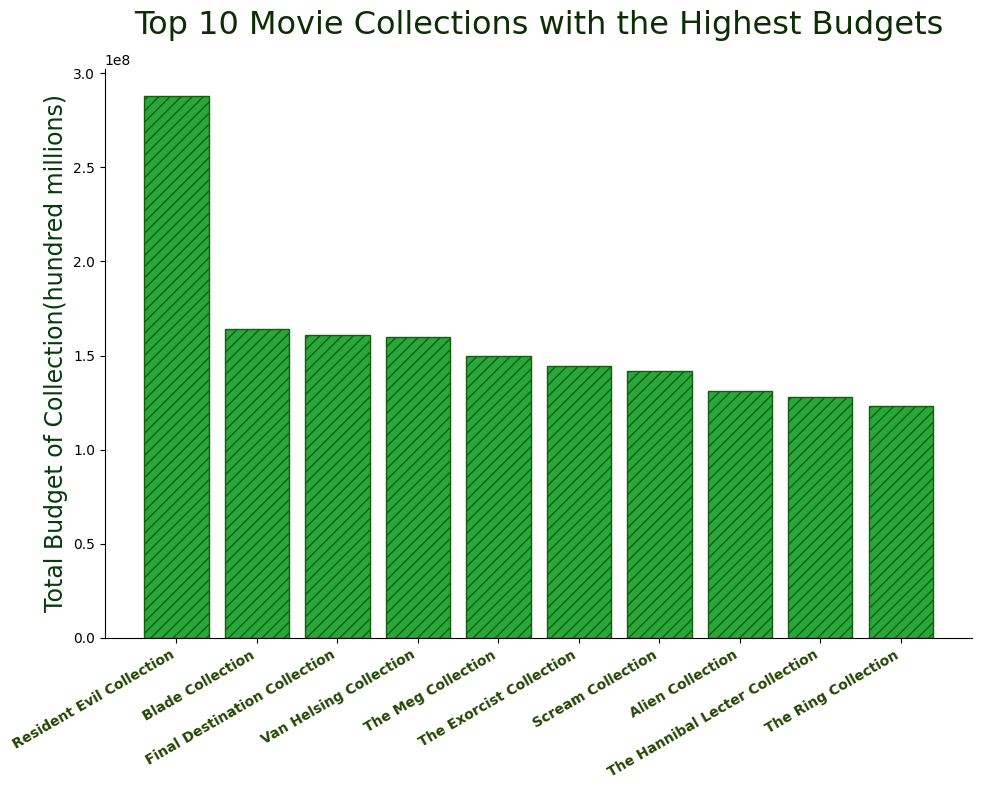

In [1548]:
category = "collection_name"
values = "budget"
movie_collection_budget = horror_df.groupby(category)[values].sum()
movie_coll_budget = movie_collection_budget.sort_values(ascending=False) 

collection_budget_10 = movie_coll_budget.head(10)



plt.figure(figsize=(10,8))
plt.bar(collection_budget_10.index, collection_budget_10.values, color= "#27A73C", edgecolor= "#145f0a", hatch= "///")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Top 10 Movie Collections with the Highest Budgets",
          fontsize= 23,
          color= "#0B2E02",
          pad= 25,
          loc="center")

plt.ylabel("Total Budget of Collection(hundred millions)", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

custom_labels = collection_budget_10.index
ax.set_xticklabels(custom_labels, color = "#234603",  fontsize=10, fontweight="bold", rotation=30, ha="right")

plt.tight_layout()
plt.savefig('../Visualizations/top_movie_collection_budget.png')
plt.show()


Instead of Budget let's look at popularity, tmdb rating, to see how that differs from highest revenues.
In theory, the higher the popularity the higher the revenue.... 
But we can't forget cult classics! Might be low revenue... but high popularity? 

C:\Users\jessi\AppData\Local\Temp\ipykernel_8904\2802410486.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_labels, color = "#234603", fontsize=10, fontweight="bold", rotation=30, ha="right")


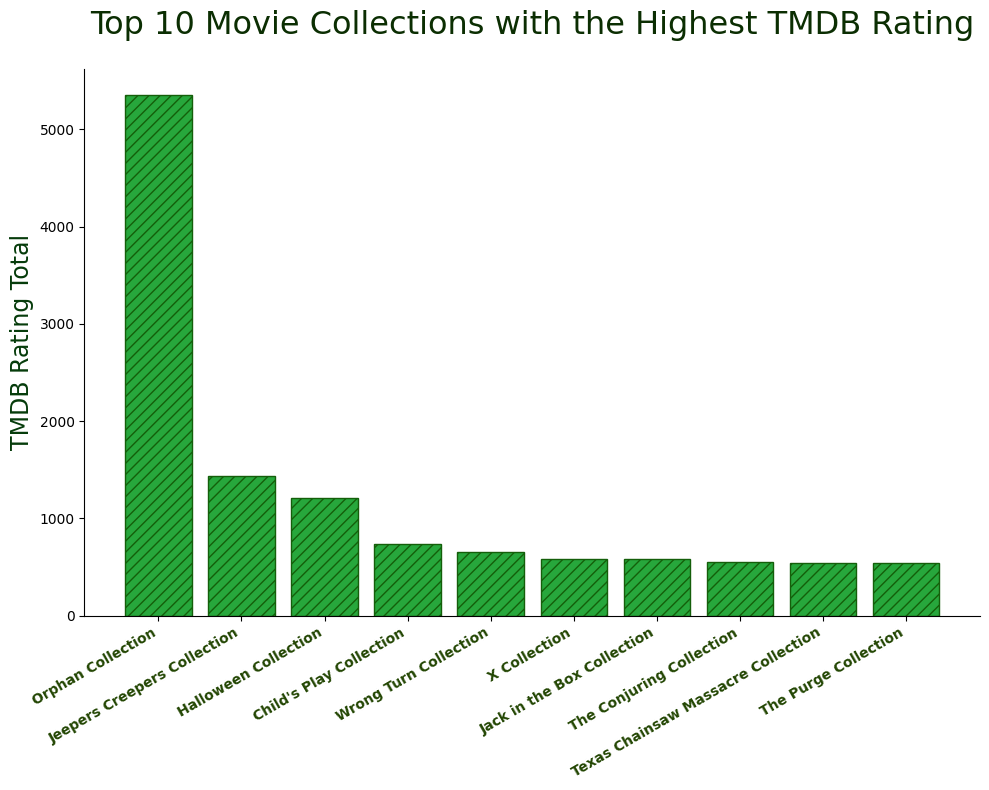

In [1549]:
category = "collection_name"
values = "tmdb_rating"
movie_collection_pop = horror_df.groupby(category)[values].sum()
movie_coll_pop = movie_collection_pop.sort_values(ascending=False) 

collection_pop_10 = movie_coll_pop.head(10)



plt.figure(figsize=(10,8))
plt.bar(collection_pop_10.index, collection_pop_10.values, color= "#27A73C", edgecolor= "#145f0a", hatch= "///")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Top 10 Movie Collections with the Highest TMDB Rating",
          fontsize= 23,
          color= "#0B2E02",
          pad= 25,
          loc="center")

plt.ylabel("TMDB Rating Total", color= "#053B0A", fontsize=17)
plt.xticks(rotation=45, ha="right")

custom_labels = collection_pop_10.index
ax.set_xticklabels(custom_labels, color = "#234603", fontsize=10, fontweight="bold", rotation=30, ha="right")

plt.tight_layout()
plt.savefig('../Visualizations/top_movie_collection_pop.png')
plt.show()

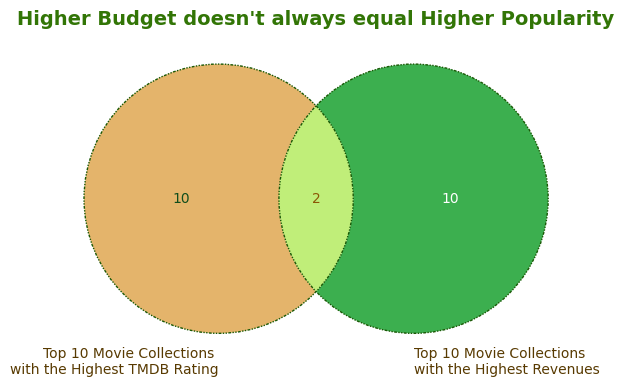

Top 10 horror movie collections with highest revenues:
collection_name
Resident Evil Collection          1233421727
It Collection                     1174965076
Saw Collection                     977089863
Paranormal Activity Collection     886011827
The Conjuring Collection           840887456
Jaws Collection                    798405075
Annabelle Collection               794816136
Scream Collection                  744475660
Final Destination Collection       666766477
Halloween Collection               652766751
Name: revenue, dtype: int64
Top 10 horror movies collections with highest TMDB Rating:
collection_name
Resident Evil Collection                        288000000
Blade Collection                                164000000
Final Destination Collection                    161000000
Van Helsing Collection                          160000000
The Meg Collection                              150000000
                                                  ...    
Ammar [Seri]                

In [1550]:
# doing the exact same as previous Venn but instead of budget, using popularity(tmdb rating)
movie_collection_revenue = horror_df.groupby('collection_name')['revenue'].sum()
movie_coll_rev = movie_collection_revenue.sort_values(ascending=False).head(10)
movie_coll_rev = pd.Series(movie_coll_rev) 

movie_collection_rate = horror_df.groupby('collection_name')['tmdb_rating'].sum()
movie_coll_rate = movie_collection_budget.sort_values(ascending=False).head(10)
movie_coll_rate = pd.Series(movie_coll_budget) 

lside = movie_coll_rate.index
rside = movie_coll_rev.index
middle = set(lside).intersection(set(rside))


venn = venn2(subsets = (10, 10, 2),
    set_labels = ('Top 10 Movie Collections \nwith the Highest TMDB Rating', 'Top 10 Movie Collections \nwith the Highest Revenues'), 
    set_colors=("#E2AC5B", "#27A73C"),
    alpha= 0.9)

venn2_circles(subsets=(10,10,2),
            color= "#195805",
            linestyle= (0, (2, 1, 1, 1, 1, 1)),
            linewidth= 1) 

venn.set_labels[0].set_fontsize(10)
venn.set_labels[1].set_fontsize(10)
venn.set_labels[0].set_color("#583a01")
venn.set_labels[1].set_color("#583a01")

if venn.get_label_by_id('10'):  # leftside
    venn.get_label_by_id('10').set_color( "#114D1B")

if venn.get_label_by_id('01'):  # rigthside
    venn.get_label_by_id('01').set_color('white')

if venn.get_label_by_id('11'):  # intersection
    venn.get_label_by_id('11').set_color("#8B5605")


plt.title("Higher Budget doesn't always equal Higher Popularity",
        color= "#327506",
        fontsize=14,
        fontweight="bold",
        pad= 5)

plt.tight_layout()
plt.savefig('../Visualizations/collrev_rating_Venn.png')
plt.show()



print("Top 10 horror movie collections with highest revenues:")
print(movie_coll_rev)
print("Top 10 horror movies collections with highest TMDB Rating:")
print(movie_coll_rate)
print("Horror movie collections that are in both lists: (top 10 highest revenue & top ten highest tmdb rating for horror movie collections)")
print(middle)


let's take a step back from horror and look at top-rated films  
what they did right...   
  
  
### Cinatomy Dataset:   
1,000 well-known films (sourced from IMDb's top-rated titles)
  (999 after cleaning/wrangling)
  Top 1000 Films of All Time  
__from IMDB's WEBSITE:__  
List of top 1000 movies, ranked starting with #1. Rankings are arrived at by combining ratings and percentages from five prominent movie databases: Metacritic, Rotten Tomatoes, IMDb, TCM, and Sight & Sound. Additional points are given to films repeatedly appearing on lists (created by respected critics, film directors, and various publications) of top films.  
   


I think it's safe to say Horror Movies are typically not considered family friendly, 
does that automatically knock the genre out of being considered "Great"?  

histogram below shows majority of movies considered in the top 1000 films of all time are not family friendly.

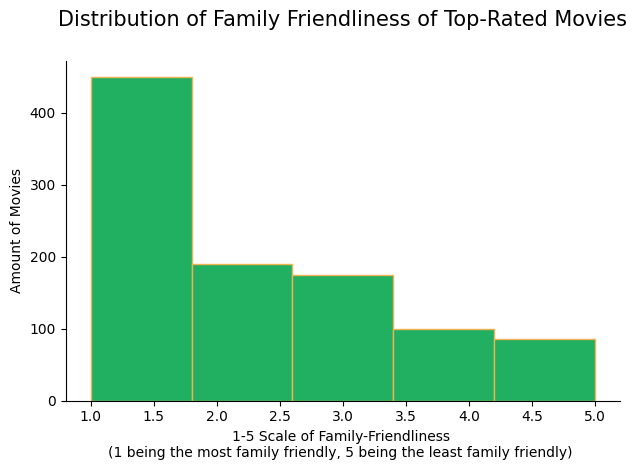

In [1551]:
cin_df['family_friendly'].hist(bins=5, color="#21AF61", edgecolor="#F1B254")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('1-5 Scale of Family-Friendliness \n(1 being the most family friendly, 5 being the least family friendly) ')
plt.ylabel('Amount of Movies')
plt.title("Distribution of Family Friendliness of Top-Rated Movies", color= "#030103", pad=25, fontsize=15)


plt.tight_layout()
plt.savefig('../Visualizations/familyfriendly_hist.png')
plt.show()

### So what do we need for The Perfect Horror Movie?
Looking at top rated movies can show us what we need to create the perfect horror movie...  
let's take a look at:  
-originality  
-impactful  
-immersive  

originality scaled by --- "How fresh and unconventional the film's concept and execution feel. 1 = highly derivative, 5 = highly original."
would it have been better to split into original story and unique execution of a story? 

impactful scaled by --- "How memorable and resonant the film is afterward. 1 = instantly forgettable, 5 = leaves a massive lasting"


immersive scaled by --- "How absorbing the viewing experience is. 1 = disconnecting, 5 = hypnotic / fully immersive environment"


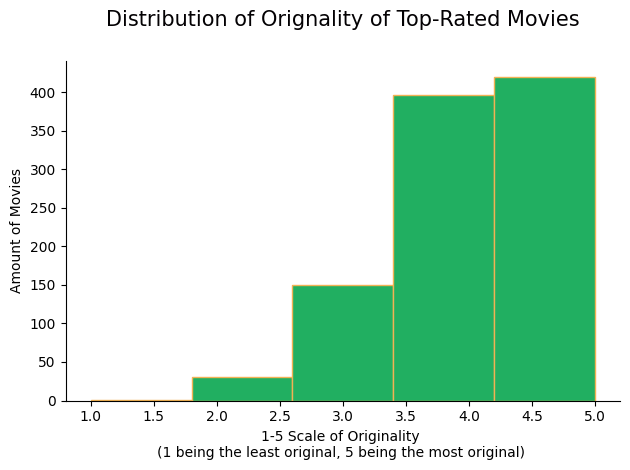

In [1552]:
cin_df['originality'].hist(bins=5, color="#21AF61", edgecolor="#F1B254")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('1-5 Scale of Originality \n(1 being the least original, 5 being the most original) ')
plt.ylabel('Amount of Movies')
plt.title("Distribution of Orignality of Top-Rated Movies", color= "#030103", pad=25, fontsize=15)


plt.tight_layout()
plt.savefig('../Visualizations/originality_hist.png')
plt.show()

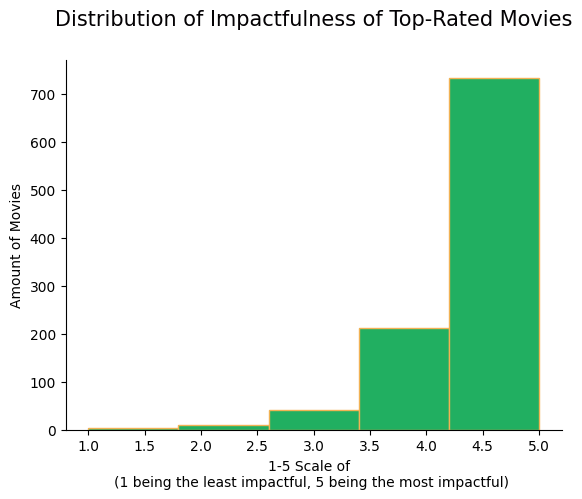

In [1553]:
cin_df['impactful'].hist(bins=5, color="#21AF61", edgecolor="#F1B254")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('1-5 Scale of  \n(1 being the least impactful, 5 being the most impactful) ')
plt.ylabel('Amount of Movies')
plt.title("Distribution of Impactfulness of Top-Rated Movies", color= "#030103", pad=25, fontsize=15)

plt.savefig('../Visualizations/impactful_hist.png')
plt.show()

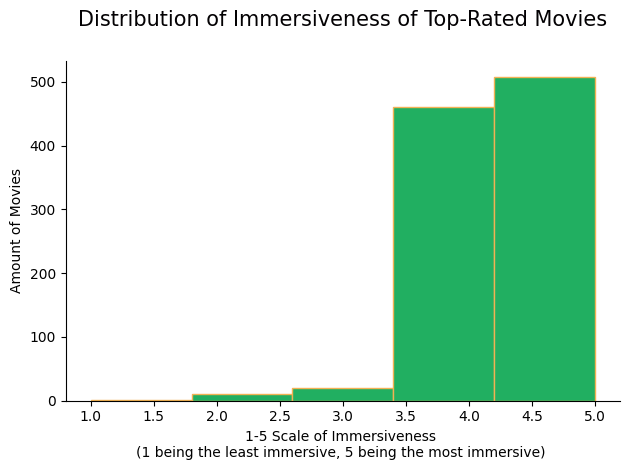

In [1554]:
cin_df['immersive'].hist(bins=5, color="#21AF61", edgecolor="#F1B254")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('1-5 Scale of Immersiveness \n(1 being the least immersive, 5 being the most immersive) ')
plt.ylabel('Amount of Movies')
plt.title("Distribution of Immersiveness of Top-Rated Movies", color= "#030103", pad=25, fontsize=15)

plt.tight_layout()
plt.savefig('../Visualizations/immersive_hist.png')
plt.show()

From these three plots, we can see how impactful a movie is can get it a higher rating than how original or immersive the movie is; though all three categories seem significant. 

Taking my highest revenue horror movies and running them through a function to check if they are in the cinatomy dataframe.

In [1555]:

def in_cinatomy(title):
    if title in cin_df['title'].values:
        matching_row = cin_df[cin_df['title'] == title]
        print(f" '{title}' is found in cinatomy dataframe")
    else:
        print(f" '{title}' NOT found in this DataFrame")


in_cinatomy("It")
in_cinatomy("World War Z")
in_cinatomy("The Meg")
in_cinatomy("It Chapter Two")
in_cinatomy("Jaws")
in_cinatomy("The Exorcist")
in_cinatomy("The Mummy")
in_cinatomy("Halloween")
in_cinatomy("The Nun")
in_cinatomy("A Quiet Place")


 'It' NOT found in this DataFrame
 'World War Z' NOT found in this DataFrame
 'The Meg' NOT found in this DataFrame
 'It Chapter Two' NOT found in this DataFrame
 'Jaws' is found in cinatomy dataframe
 'The Exorcist' is found in cinatomy dataframe
 'The Mummy' NOT found in this DataFrame
 'Halloween' is found in cinatomy dataframe
 'The Nun' NOT found in this DataFrame
 'A Quiet Place' NOT found in this DataFrame


 
"The 1,000 films skew acclaimed (IMDb top-rated), so scores lean positive overall. This dataset is better suited for relative comparisons than for separating good films from bad ones." - Cinatomy Dataset Author

three of our top highest rev in horror are found in cin_df, lets take a close look at them 

In [1556]:
# creating a new dataframe of the horror movies that are the cinatomy dataframe and also in the top ten highest revenue horror movies list

jaws_occurence = cin_df.loc[cin_df['title'] == "Jaws"]
te_occurence = cin_df.loc[cin_df['title'] == "The Exorcist"]
hw_occurence = cin_df.loc[cin_df['title'] == "Halloween"]

toprev_incin = pd.concat([jaws_occurence, te_occurence, hw_occurence], axis=0)

toprev_incin

,title,pacing_efficiency,originality,family_friendly,plot_quality_rating,plot_quality_reasons_for_liking,plot_quality_reasons_for_disliking,dialogues,end_feeling_emotional_adjective,end_feeling_ending_rating,...,sound_bgm_quality,sound_song_tracks_quality,performance_of_actors,connected,references_contained,cognitive_requirement,technical_knowledge_required,photosensitivity_warnings,animal_harm,trailer_or_spoiler
415,Jaws,4,5,2,5,"['strong_pacing', 'tight_structure']",[],5,energized,5,...,5,1,5,4,1,2,1,1,5,1
419,The Exorcist,3,5,1,5,"['unpredictable', 'strong_pacing', 'tight_stru...",[],4,bittersweet,5,...,5,4,5,1,2,3,1,3,1,5
844,Halloween,3,4,1,4,"['unpredictable', 'strong_pacing', 'tight_stru...",[],3,energized,5,...,5,3,4,1,1,1,1,2,1,3


All three movies list "strong pacing" and "tight structure" as "plot quality reasons for liking".  
pacing effficiency scaled by --- "How efficiently the film moves. 1 = dragged, 3 = deliberate / slow-burn, 5 = perfectly fast / thrilling pacing."-cinatomy dataset
But none have a 5 score. they fall on deliberate/slowburn to (Jaws leaning towards)thrilling pace.


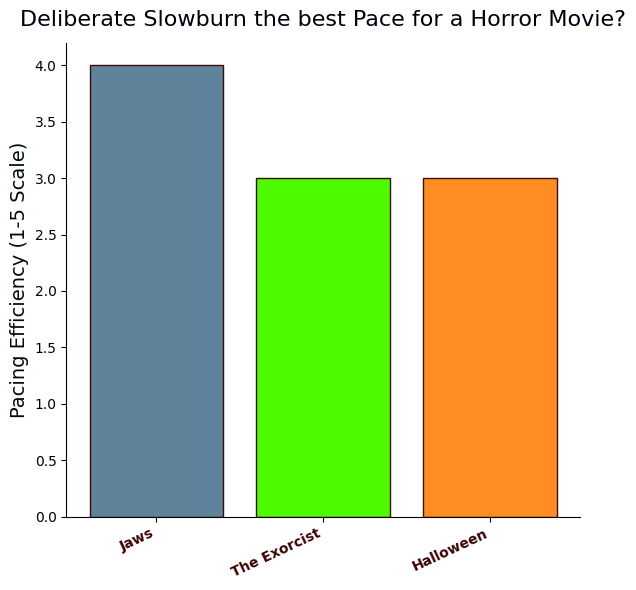

In [1557]:

cintitle = toprev_incin['title']
pacing_3 = toprev_incin['pacing_efficiency']

colors = ["#5F839B", "#4ffa00", "#ff8d22"]

plt.figure(figsize=(6,6))
plt.bar(cintitle, pacing_3, color= colors, edgecolor= "#3d0e02")
ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.title("Deliberate Slowburn the best Pace for a Horror Movie?",
          fontsize= 16,
          color= "#01000C",
          pad= 12,
          loc="center")

plt.ylabel("Pacing Efficiency (1-5 Scale)", color= "#010E03", fontsize=14)
plt.xticks(rotation=25, ha="right", color= "#3b0303", fontweight= "bold")



plt.tight_layout()
plt.savefig('../Visualizations/pacing_3hor.png')
plt.show()

dialogues scaled by --- "Quality of dialogue writing. 1 = stilted / exposition-heavy, 5 = sharp and authentic."    
perforamnce of actors scaled by --- "Quality of the cast's acting performances."  
plot quality rating scaled by --- Overall quality of the plot and story construction.

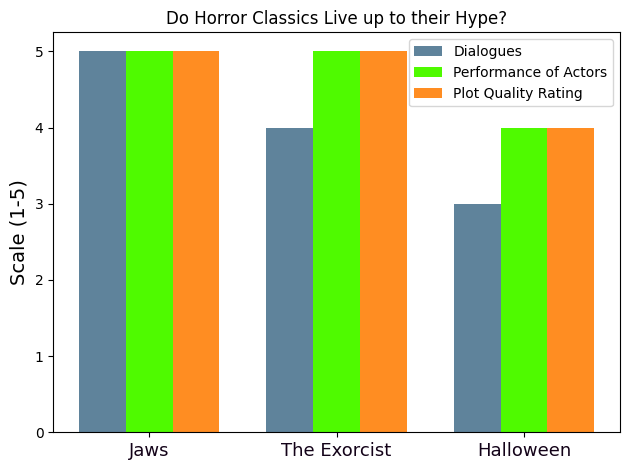

In [1558]:
#bars/height
dia_3 = toprev_incin['dialogues']
perf_3 = toprev_incin['performance_of_actors']
plot_3 = toprev_incin['plot_quality_rating']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, dia_3, width=bar_width, label='Dialogues', color="#5F839B")
ax.bar(x, perf_3, width=bar_width, label='Performance of Actors', color="#4ffa00")
ax.bar(x + bar_width, plot_3, width=bar_width, label='Plot Quality Rating', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title('Do Horror Classics Live up to their Hype?')
ax.legend()

plt.tight_layout()

plt.savefig('../Visualizations/dia_perf_3hor.png')
plt.show()

Already looked at the overall scores of the Dataset for  
-originality  
-impactful  
-immersive  

Looking at our three movies (in top 10 rev), how do they rate 

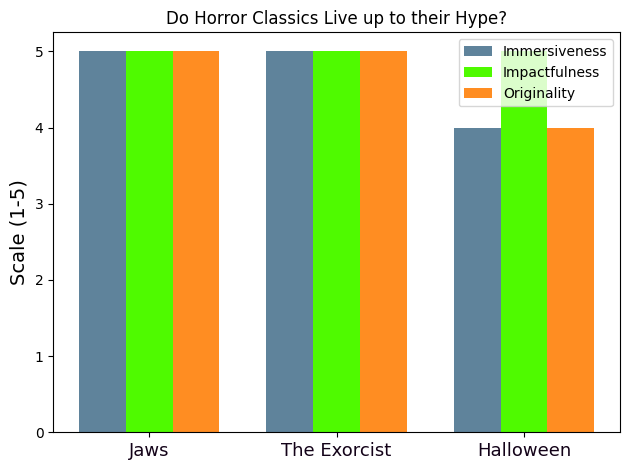

In [1559]:
#bars/height
imm_3 = toprev_incin['immersive']
imp_3 = toprev_incin['impactful']
orig_3 = toprev_incin['originality']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, imm_3, width=bar_width, label='Immersiveness', color="#5F839B")
ax.bar(x, imp_3, width=bar_width, label='Impactfulness', color="#4ffa00")
ax.bar(x + bar_width, orig_3, width=bar_width, label='Originality', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title('Do Horror Classics Live up to their Hype?')
ax.legend()

plt.tight_layout()

plt.savefig('../Visualizations/immimporig_3hor.png')
plt.show()

### Bechdel Score DataFrame

"This dataset covers information about more than 9000 movies such as their titles, genres, ratings on IMDb and scores to the Bechdel test. It is a test invented in 1985 by Alison Bechdel which consists in the measure of women’s representation in movies. To pass the test, the film must have two women named in it (score 1 to the test, 0 otherwise) who talk to each other (score 2) about anything else than a man (score 3).

The movies' release dates go from 1894 to 2024."

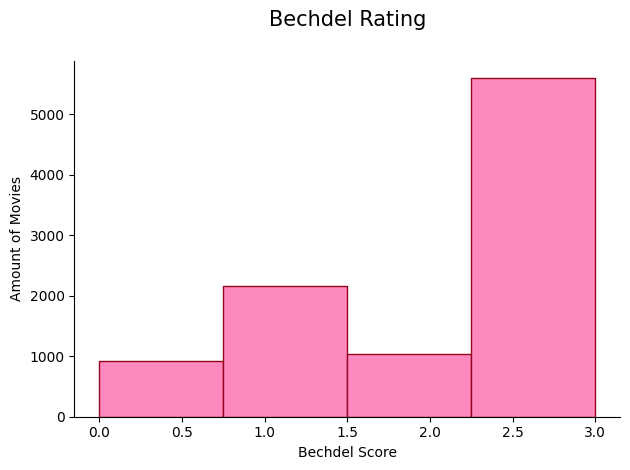

In [1560]:
bech_df['bechdel_rating'].hist(bins=4, color="#FD89BF", edgecolor="#94051D")

plt.grid(False) 
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel('Bechdel Score')
plt.ylabel('Amount of Movies')
plt.title("Bechdel Rating", color= "#030103", pad=25, fontsize=15)

plt.tight_layout()
plt.savefig('../Visualizations/bechrating_hist.png')
plt.show()

Because we are given little information on how the movies in this dataframe were decided, a majority of them passing the bechdel test isn't really conclusive of any insight for sure. But we can check some movies we have our eye on (highest rev, popularity, etc.) for their scores. 

In [1561]:
score_0 = bech_df.loc[bech_df['bechdel_rating'] == 0]
score_1 = bech_df.loc[bech_df['bechdel_rating'] == 1]
score_2 = bech_df.loc[bech_df['bechdel_rating'] == 2]
score_3 = bech_df.loc[bech_df['bechdel_rating'] == 3]

def bech_test_score(title):
    if title in bech_df['title'].values:
        if title in score_0['title'].values:
            print(f"{title}'s score: 0")
        if title in score_1['title'].values:
            print(f"{title}'s score: 1")
        if title in score_2['title'].values:
            print(f"{title}'s score: 2")
        if title in score_3['title'].values:
            print(f"{title}'s score: 3")
        else:
            print("Error")
    else:
        print(f"{title}: not found in dataframe")

# use our function to check bechdel test score of top highest revenue 10 horror movies 
bech_test_score("It")
bech_test_score("World War Z")
bech_test_score("The Meg")
bech_test_score("It Chapter Two")
bech_test_score("Jaws")
bech_test_score("The Exorcist")
bech_test_score("The Mummy")
bech_test_score("Halloween")
bech_test_score("The Nun")
bech_test_score("A Quiet Place")


It's score: 3
World War Z's score: 3
The Meg: not found in dataframe
It Chapter Two: not found in dataframe
Jaws's score: 3
The Exorcist: not found in dataframe
The Mummy: not found in dataframe
Halloween's score: 3
The Nun: not found in dataframe
A Quiet Place's score: 3


Five of the movies from our Top 10 highest revenue Horror movies(horror_df) are not found in the bech_df.
But of the remaining 5 that were in both datasets, they all scored a 3 on the bechdel test scale. 
This is not definitive, but does point in the direction... passing the bechdel test is important to consumers.  
(a win for feminism!)

In [1562]:
three_rating = bech_df[bech_df['bechdel_rating'] == 3]
three_rating

# plot movie_genres.values_count() with three rating

,title,release_date,imdbid,bechdel_rating,imdb_rating,imdb_votes,runtime,movie_genres
5,Gretchen the Greenhorn,1970-01-01 00:00:00.000001916,6745.0,3,6.4,537.0,58.0,"Crime, Drama, Romance"
7,Lady Windermere&#39;s Fan,1970-01-01 00:00:00.000001916,279914.0,3,5.3,66.0,66.0,"Drama, Comedy"
8,Snow White,1970-01-01 00:00:00.000001916,7361.0,3,6.3,444.0,63.0,"Fantasy, Romance"
10,A Tale of Two Cities,1970-01-01 00:00:00.000001917,8652.0,3,6.1,163.0,70.0,"Romance, Drama, History"
11,"Poor Little Rich Girl, The",1970-01-01 00:00:00.000001917,8443.0,3,6.7,1550.0,78.0,"Drama, Comedy, Family"
...,...,...,...,...,...,...,...,...
9712,Kung Fu Panda 4,1970-01-01 00:00:00.000002024,21692408.0,3,6.3,39606.0,94.0,"Animation, Adventure, Action"
9714,Love Lies Bleeding,1970-01-01 00:00:00.000002024,19637052.0,3,6.7,23333.0,104.0,"Crime, Adventure, Action"
9715,Mean Girls,1970-01-01 00:00:00.000002024,11762114.0,3,5.7,28257.0,112.0,"Musical, Comedy"
9716,Megamind vs. The Doom Syndicate,1970-01-01 00:00:00.000002024,31122323.0,3,2.4,4076.0,83.0,"Animation, Adventure, Action"


### Oscars Dataframe

"This data contains the Oscar Best Picture winners and nominees."

In [1563]:
osc_df.head()

,title,osc_nomination,osc_win,oscar_year,studio_producer,runtime,imdb_rating,overview,critic_consensus,content_rating,directors,authors,release_date,production_company,tomatometer_status,tomatometer_rating,movie_genres
0,12 Years a Slave,0,1,2013,"Brad Pitt, Dede Gardner, Jeremy Kleiner, Steve...",134.0,8.1,"In the years before the Civil War, Solomon Nor...","It's far from comfortable viewing, but 12 Year...",R,Steve McQueen (III),John Ridley,2013-10-18,Fox Searchlight,Certified-Fresh,95.0,"Biography, Drama, History"
1,127 Hours,1,0,2010,"Danny Boyle, John Smithson, and Christian Colson",94.0,7.5,"While exploring a remote canyon in Utah, mount...","As gut-wrenching as it is inspirational, 127 H...",R,Danny Boyle,"Danny Boyle, Simon Beaufoy",2010-11-05,Fox Searchlight,Certified-Fresh,93.0,"Biography, Drama"
2,42nd Street,1,0,1932/33,Warner Bros.,89.0,7.4,When revered Broadway director Julian Marsh (W...,"Bubsy Berkeley does it again in 42nd Street, a...",NR,Lloyd Bacon,"Rian James, James Seymour, Whitney Bolton",1933-03-09,MGM Home Entertainment,Fresh,96.0,"Musical & Performing Arts, Musical, Drama, Comedy"
3,A Beautiful Mind,0,1,2001,Brian Grazer and Ron Howard,135.0,8.2,A human drama inspired by events in the life o...,The well-acted A Beautiful Mind is both a movi...,PG-13,Ron Howard,Akiva Goldsman,2001-12-21,Universal Pictures,Certified-Fresh,74.0,"Biography, Drama"
4,A Clockwork Orange,1,0,1971,Stanley Kubrick,136.0,8.3,"In an England of the future, Alex (Malcolm McD...","Disturbing and thought-provoking, A Clockwork ...",R,Stanley Kubrick,Stanley Kubrick,1971-12-19,Warner Bros.,Certified-Fresh,88.0,"Mystery & Suspense, Science Fiction & Fantasy,..."


## SQL queries

In [1603]:
nom_query = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview, ratings.osc_nomination, ratings.oscar_year
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE movies.movie_genres LIKE "%Horror%" AND ratings.osc_nomination >= 1
ORDER BY movies.release_date DESC;
"""
pd.read_sql(nom_query, connection)

,title,movie_id,overview,osc_nomination,oscar_year
0,The Letter,24350,A boy discovered an mysterious letter.,1.0,1940
1,Ghost,9207,"The story of the film follows Karan Khanna, a ...",1.0,1990
2,Z,29081,A family find themselves terrorized by their e...,1.0,1969
3,Gaslight,9131,"One night, a bar waitress encounters a mysteri...",1.0,1944
4,Babe,2199,"A woman is concerned about her boyfriend, who ...",1.0,1995
5,Milk,14590,"On a late night, a young teen goes into the ki...",1.0,2008
6,Get Out,9192,Chris and his girlfriend Rose go upstate to vi...,1.0,2017
7,Darling,5762,A young woman slowly goes crazy after taking a...,1.0,1965
8,The Thin Man,25991,A struggling You Tuber Bayden Redshaw and his ...,1.0,1934
9,Awakenings,2142,"Chased by a malevolent entity, a babysitter's ...",1.0,1990


In [1606]:
win_query = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview, ratings.osc_win, ratings.oscar_year
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE movies.movie_genres LIKE "%Horror%" AND ratings.osc_win >= 1
ORDER BY ratings.oscar_year;
"""
pd.read_sql(win_query, connection)

,title,movie_id,overview,osc_win,oscar_year
0,Hamlet,10003,A young Prince is visited by the Ghost of his ...,1.0,1948
1,The Apartment,21726,the misadventures of a man in his apartment.,1.0,1960
2,The Artist,21748,Peter as an artist is dangerously obsessed wit...,1.0,2011


Jaws and The Exorcist (which we have already taken a more indepth look at) were both nominated for Oscar Best Picture, no win. 

In [ ]:
query1975 = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview, ratings.osc_win, ratings.osc_nomination
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE ratings.oscar_year = 1975;
"""
pd.read_sql(query1975, connection)

,title,movie_id,overview,osc_win,osc_nomination
0,Barry Lyndon,2429,NaN,0.0,1.0
1,Dog Day Afternoon,6948,NaN,0.0,1.0
2,Jaws,12111,When an insatiable great white shark terrorize...,0.0,1.0
3,Nashville,15414,NaN,0.0,1.0
4,One Flew Over the Cuckoo's Nest,16330,NaN,1.0,0.0


In [1610]:
query1973 = """ 
SELECT DISTINCT movies.title, movies.movie_id, movies.overview, ratings.osc_win, ratings.osc_nomination
FROM movies
JOIN ratings on ratings.movie_id = movies.movie_id
WHERE ratings.oscar_year = 1973;
"""
pd.read_sql(query1973, connection)

,title,movie_id,overview,osc_win,osc_nomination
0,A Touch of Class,792,NaN,0.0,1.0
1,American Graffiti,1404,NaN,0.0,1.0
2,Cries and Whispers,5176,NaN,0.0,1.0
3,The Exorcist,23101,12-year-old Regan MacNeil begins to adapt an e...,0.0,1.0
4,The Sting,25811,NaN,1.0,0.0


check if the movie that won in in cin_df
how does it compare?
Halloween did score lower than The Exorcist and Jaws overall in the cinatomy categories. 

In [ ]:
# using our function to see if the Oscar Best Pictures the Year The Exorcist and the year Jaws were nominated are in the cinatomy dataframe
in_cinatomy("One Flew Over the Cuckoo's Nest")
in_cinatomy("The Sting")

 'One Flew Over the Cuckoo's Nest' is found in cinatomy dataframe
 'The Sting' is found in cinatomy dataframe


Setting up two new dataframes to visually compare.

In [ ]:
# 1975

jaws_occurence = cin_df.loc[cin_df['title'] == "Jaws"]
ofo_occurence = cin_df.loc[cin_df['title'] == "One Flew Over the Cuckoo's Nest"]
jaws_vs_ofo = pd.concat([jaws_occurence, ofo_occurence], axis=0)

# 1973
te_occurence = cin_df.loc[cin_df['title'] == "The Exorcist"]
ts_occurence = cin_df.loc[cin_df['title'] == "The Sting"]
te_vs_ts = pd.concat([te_occurence, ts_occurence], axis=0)



,title,pacing_efficiency,originality,family_friendly,plot_quality_rating,plot_quality_reasons_for_liking,plot_quality_reasons_for_disliking,dialogues,end_feeling_emotional_adjective,end_feeling_ending_rating,...,sound_bgm_quality,sound_song_tracks_quality,performance_of_actors,connected,references_contained,cognitive_requirement,technical_knowledge_required,photosensitivity_warnings,animal_harm,trailer_or_spoiler
419,The Exorcist,3,5,1,5,"['unpredictable', 'strong_pacing', 'tight_stru...",[],4,bittersweet,5,...,5,4,5,1,2,3,1,3,1,5
112,The Sting,4,4,3,5,"['unpredictable', 'plot_twists', 'strong_pacin...",[],5,energized,5,...,5,5,5,1,1,4,1,1,1,5


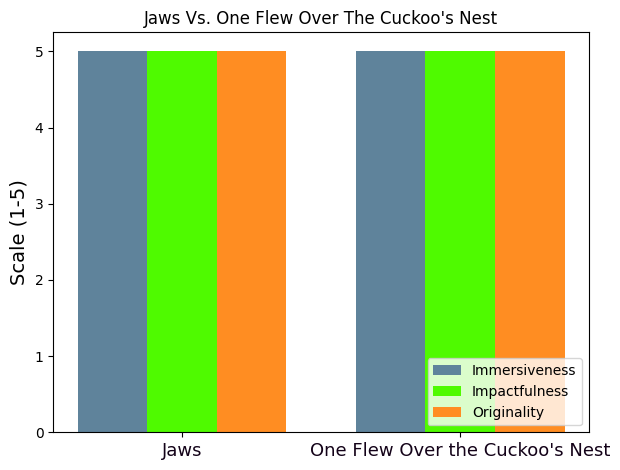

In [1639]:
cintitle = jaws_vs_ofo['title']


#bars/height
imm_1975 = jaws_vs_ofo['immersive']
imp_1975 = jaws_vs_ofo['impactful']
orig_1975 = jaws_vs_ofo['originality']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, imm_1975, width=bar_width, label='Immersiveness', color="#5F839B")
ax.bar(x, imp_1975, width=bar_width, label='Impactfulness', color="#4ffa00")
ax.bar(x + bar_width, orig_1975, width=bar_width, label='Originality', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("Jaws Vs. One Flew Over The Cuckoo's Nest")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/jaws_vs_ofoIMIMOR.png')
plt.show()

neck to neck.... what other can we compare?


end feeling end rating ---  "Overall quality rating of the ending itself"

overall feeling ---"The model's holistic overall impression/enjoyment rating of the film."

plot quality rating --- "Overall quality of the plot and story construction."

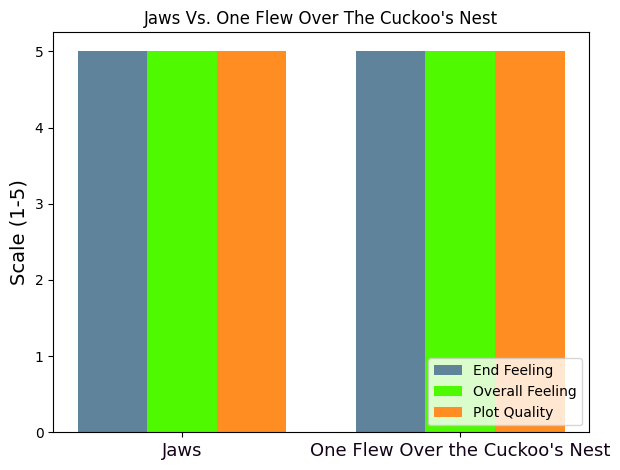

In [1640]:
cintitle = jaws_vs_ofo['title']


#bars/height
end_1975 = jaws_vs_ofo['end_feeling_ending_rating']
over_1975 = jaws_vs_ofo['overall_feeling']
plot_1975 = jaws_vs_ofo['plot_quality_rating']

#sets
n = len(cintitle)
bar_width = 0.25
x = np.arange(n)

fig, ax = plt.subplots()
ax.bar(x - bar_width, end_1975, width=bar_width, label='End Feeling', color="#5F839B")
ax.bar(x, over_1975, width=bar_width, label='Overall Feeling', color="#4ffa00")
ax.bar(x + bar_width, plot_1975, width=bar_width, label='Plot Quality', color="#ff8d22")


ax.set_xticks(x)
ax.set_xticklabels(cintitle, color="#130218", fontsize= 13)
ax.set_ylabel('Scale (1-5)', fontsize= 14)
ax.set_title("Jaws Vs. One Flew Over The Cuckoo's Nest")
ax.legend(loc= "lower right")

plt.tight_layout()

plt.savefig('../Visualizations/jaws_vs_ofoEFOVPQ.png')
plt.show()

In [1641]:
jaws_vs_ofo

,title,pacing_efficiency,originality,family_friendly,plot_quality_rating,plot_quality_reasons_for_liking,plot_quality_reasons_for_disliking,dialogues,end_feeling_emotional_adjective,end_feeling_ending_rating,...,sound_bgm_quality,sound_song_tracks_quality,performance_of_actors,connected,references_contained,cognitive_requirement,technical_knowledge_required,photosensitivity_warnings,animal_harm,trailer_or_spoiler
415,Jaws,4,5,2,5,"['strong_pacing', 'tight_structure']",[],5,energized,5,...,5,1,5,4,1,2,1,1,5,1
17,One Flew Over the Cuckoo's Nest,3,5,1,5,"['unpredictable', 'strong_pacing', 'tight_stru...",[],5,bittersweet,5,...,4,3,5,1,1,4,1,1,1,5
